<a href="https://colab.research.google.com/github/deviapujiastuti/image-processing/blob/main/ip_FourierTransform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

f = np.array([
    [148, 164, 174],
    [144, 159, 167],
    [128, 147, 157]
], dtype=float)

print("=== MATRIKS CITRA ASLI f(x,y) ===")
print(f)
print("\n" + "="*40 + "\n")

=== MATRIKS CITRA ASLI f(x,y) ===
[[148. 164. 174.]
 [144. 159. 167.]
 [128. 147. 157.]]




Pada tahap awal, kita membuat sebuah array 2-dimensi berukuran $3 \times 3$ menggunakan pustaka NumPy. Angka-angka di dalam matriks ini murni diambil dari soal yang tertera pada panduan tugas mandiri. Tipe data diatur sebagai float (bilangan desimal) agar siap diproses dalam perhitungan matematis yang presisi.

In [2]:
F_uv = np.fft.fft2(f)

Langkah inti pengerjaan tugas ini adalah menerapkan rumus Transformasi Fourier Diskret pada matriks citra tersebut. Karena menghitung secara manual sangat memakan waktu, kita menggunakan fungsi bawaan NumPy yaitu np.fft.fft2(). Fungsi ini menerapkan algoritma Fast Fourier Transform (FFT) yang jauh lebih cepat daripada menghitung deret eksponensial satu per satu. Hasil dari fungsi ini adalah sebuah matriks baru berukuran $3 \times 3$ yang berisi angka-angka kompleks (memiliki bagian riil dan imajiner).

In [3]:
print("=== HASIL TRANSFORMASI FOURIER F(u,v) ===")
print("Catatan: Simbol 'j' di Python sama dengan bilangan imajiner 'i'\n")

hasil_pembulatan = np.round(F_uv, 2)

# Cetak hasil matriks
for baris in hasil_pembulatan:
    print([f"{elemen.real:.2f} + {elemen.imag:.2f}j" if elemen.imag >= 0
           else f"{elemen.real:.2f} - {abs(elemen.imag):.2f}j" for elemen in baris])

=== HASIL TRANSFORMASI FOURIER F(u,v) ===
Catatan: Simbol 'j' di Python sama dengan bilangan imajiner 'i'

['1388.00 + 0.00j', '-64.00 + 24.25j', '-64.00 - 24.25j']
['35.00 - 32.91j', '-1.00 - 3.46j', '2.00 - 5.20j']
['35.00 + 32.91j', '2.00 + 5.20j', '-1.00 + 3.46j']


Karena hasil murni dari fungsi FFT menghasilkan angka desimal yang sangat panjang di belakang koma, kita menggunakan fungsi np.round(..., 2) untuk membulatkannya menjadi 2 angka di belakang koma saja agar mudah dibaca dan disalin ke laporan. Di Python, bilangan imajiner disimbolkan dengan huruf j (di matematika biasa disimbolkan dengan i). Kode di bagian akhir bertugas mencetak setiap baris matriks secara rapi dengan format tanda tambah (+) atau kurang (-) yang disesuaikan dengan nilai imajinernya.

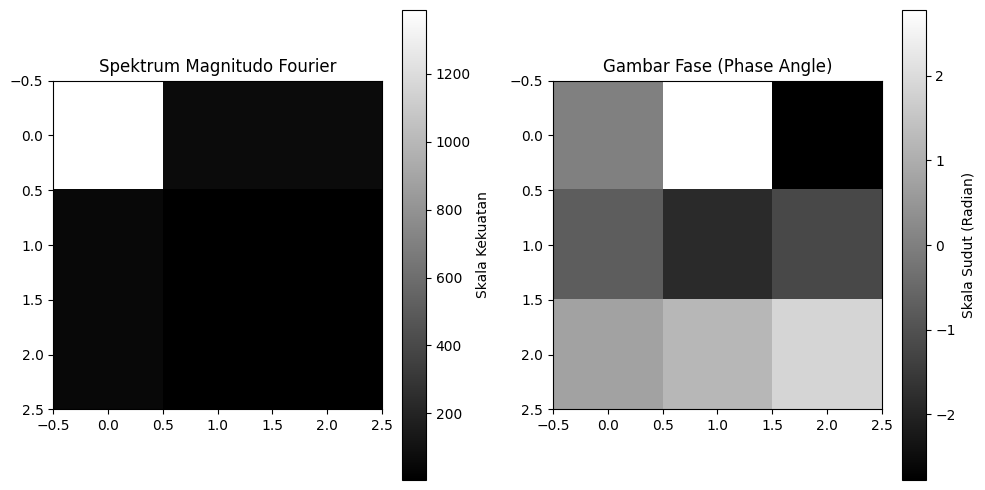

In [5]:
import matplotlib.pyplot as plt
import numpy as np

magnitudo = np.abs(F_uv)
fase = np.angle(F_uv)

plt.figure(figsize=(10, 5))

# --- Gambar 1: Spektrum Magnitudo ---
plt.subplot(1, 2, 1)
plt.imshow(magnitudo, cmap='gray')
plt.title('Spektrum Magnitudo Fourier')
plt.colorbar(label='Skala Kekuatan')

# --- Gambar 2: Gambar Fase ---
plt.subplot(1, 2, 2)
plt.imshow(fase, cmap='gray')
plt.title('Gambar Fase (Phase Angle)')
plt.colorbar(label='Skala Sudut (Radian)')

plt.tight_layout()
plt.show()